In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [4]:
df = pd.read_csv("onlinefraud.csv")

In [5]:
df = df.sample(3000000, random_state=42)

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [7]:
counts = df['isFraud'].value_counts()
print(counts)

isFraud
0    2996133
1       3867
Name: count, dtype: int64


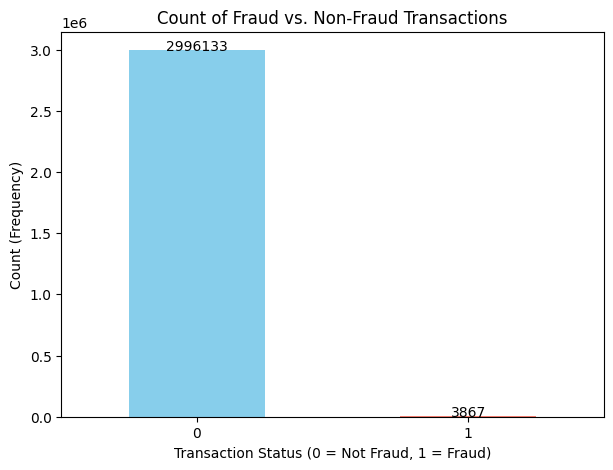

In [8]:
plt.figure(figsize=(7, 5))
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Count of Fraud vs. Non-Fraud Transactions')
plt.xlabel('Transaction Status (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Count (Frequency)')
plt.xticks(rotation=0)
for index, value in enumerate(counts):
    plt.text(index, value + 5, str(value), ha='center')

In [9]:
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [10]:
# Split features and target
X = df.drop("isFraud", axis=1).values
y = df["isFraud"].values

In [11]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [12]:
cart = DecisionTreeClassifier(
    criterion="gini",   # CART uses Gini by default
    random_state=42
)

In [13]:
cart.fit(X_train, y_train)
y_pred = cart.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9995511111111111


In [15]:
accuracy = 0.9995
remaining = 1.0 - accuracy
sizes = [accuracy, remaining]
labels = [f'Accuracy: {accuracy:.2%}', 'Error']
colors = ['skyblue', 'lightgray']
explode = [0, 0]

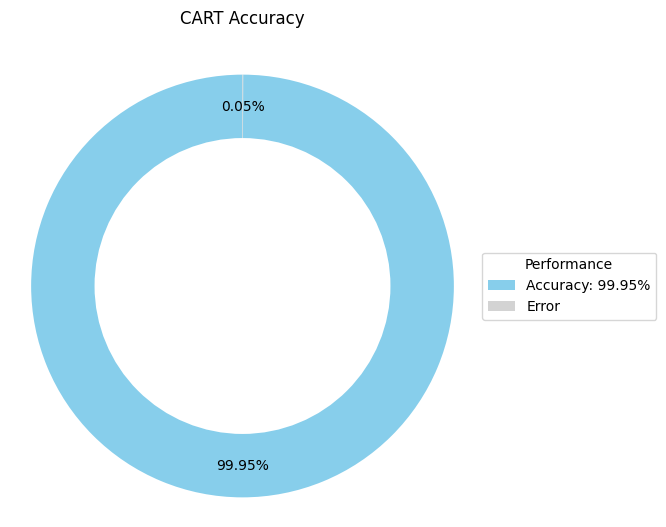

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    autopct='%1.2f%%',  
    startangle=90,      
    colors=colors,
    explode=explode,
    pctdistance=0.85   
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('CART Accuracy', y=1.05)
plt.legend(wedges, labels, title="Performance", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

ax.axis('equal')

plt.show()

In [17]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    898840
           1       0.82      0.83      0.83      1160

    accuracy                           1.00    900000
   macro avg       0.91      0.91      0.91    900000
weighted avg       1.00      1.00      1.00    900000



In [18]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(columns=['support'])
df_plot = df_report.iloc[[0, 1]][['precision', 'recall', 'f1-score']]

<Axes: >

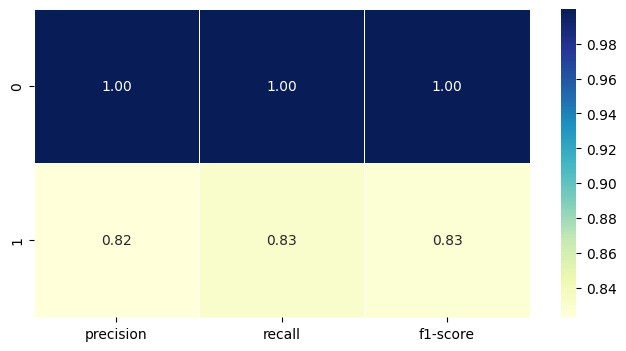

In [19]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    df_plot,
    annot=True,            # Show the numeric value in each cell
    fmt=".2f",             # Format to 2 decimal places
    cmap="YlGnBu",         # Color map (Yellow-Green-Blue is often good)
    cbar=True,             # Display the color bar
    linewidths=.5,         # Add lines for separation
)

In [20]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[898633    207]
 [   197    963]]


In [21]:
cm = confusion_matrix(y_test, y_pred)

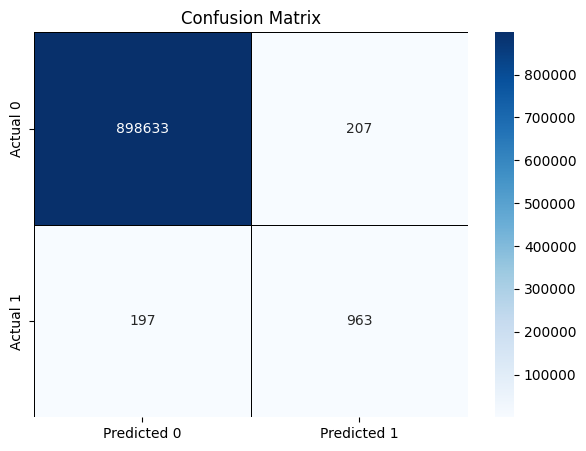

In [22]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,              # Show the numbers inside the cells
    fmt="d",                 # Format the numbers as integers (d for decimal)
    cmap='Blues',            # Color map
    linewidths=.5,           # Add lines between cells
    linecolor='black',
    
    # Set labels for the axes
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Confusion Matrix')
plt.show()

In [23]:
scores = cross_val_score(cart, X, y, cv=5, scoring='f1')  
print(f"Cross-validation scores: {scores}")
print(f"Mean score: {np.mean(scores)}")
print(f"Variance: {np.var(scores)}")

Cross-validation scores: [0.85863874 0.85128883 0.83887802 0.85657895 0.84322882]
Mean score: 0.8497226714271466
Variance: 5.7746872079331416e-05


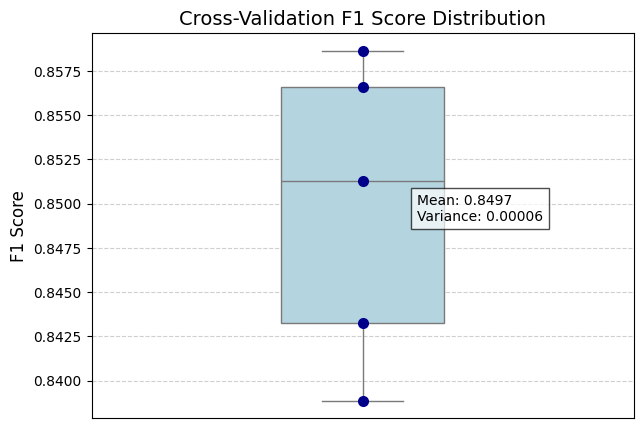

In [24]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=scores, color='lightblue', width=0.3)
sns.stripplot(y=scores, color='darkblue', size=8, jitter=False)

plt.title('Cross-Validation F1 Score Distribution', fontsize=14)
plt.ylabel('F1 Score', fontsize=12)
plt.xticks([]) # Hide x-axis labels since there's only one box
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Optional: Annotate the mean and variance on the plot
mean_score = np.mean(scores)
var_score = np.var(scores)
plt.text(0.1, mean_score, 
         f'Mean: {mean_score:.4f}\nVariance: {var_score:.5f}', 
         ha='left', va='center', 
         bbox=dict(facecolor='white', alpha=0.7))

plt.show()